In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
from google.colab import files
uploaded = files.upload()


Saving readmission_dataset.csv to readmission_dataset.csv


In [11]:
# Load dataset
df = pd.read_csv("/content/readmission_dataset.csv")

print("Dataset loaded:", df.shape)
print(df.columns.tolist())
print(df.head(2))

# Define feature list
features = [col for col in df.columns if col not in ["readmitted_30_days", "readmitted_60_days"]]


✅ Dataset loaded: (20423, 40)
['age_at_visit', 'length_of_stay', 'num_conditions', 'num_unique_drugs', 'num_procedures', 'num_measurements', 'GENDER_F', 'GENDER_M', 'RACE_asian', 'RACE_black', 'RACE_hawaiian', 'RACE_native', 'RACE_other', 'RACE_white', 'CLASS_ambulatory', 'CLASS_emergency', 'CLASS_home', 'CLASS_hospice', 'CLASS_inpatient', 'CLASS_outpatient', 'CLASS_snf', 'CLASS_urgentcare', 'CLASS_wellness', 'has_heart_disease', 'has_diabetes', 'has_copd', 'has_cancer', 'has_hypertension', 'has_kidney_disease', 'has_stroke', 'has_depression', 'is_opioid', 'is_insulin', 'is_anticoagulant', 'is_antipsychotic', 'is_antibiotic', 'is_statins', 'has_chronic_condition', 'readmitted_30_days', 'readmitted_60_days']
   age_at_visit  length_of_stay  num_conditions  num_unique_drugs  \
0            17        0.250000             1.0               0.0   
1            18        0.962222             1.0               0.0   

   num_procedures  num_measurements  GENDER_F  GENDER_M  RACE_asian  \
0   

In [ ]:
# Split the data
X = df[features]
y_30 = df["readmitted_30_days"]
y_60 = df["readmitted_60_days"]

# Split for 30-day prediction
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X, y_30, test_size=0.2, stratify=y_30, random_state=42
)

# Split for 60-day prediction 
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(
    X, y_60, test_size=0.2, stratify=y_60, random_state=42
)

print("X_train_30 shape:", X_train_30.shape)
print("y_train_30 class balance:\n", y_train_30.value_counts(normalize=True))

print("X_train_60 shape:", X_train_60.shape)
print("y_train_60 class balance:\n", y_train_60.value_counts(normalize=True))


X_train_30 shape: (16338, 38)
y_train_30 class balance:
 readmitted_30_days
0    0.505447
1    0.494553
Name: proportion, dtype: float64
X_train_60 shape: (16338, 38)
y_train_60 class balance:
 readmitted_60_days
1    0.536112
0    0.463888
Name: proportion, dtype: float64


In [ ]:
# Train XGBoost models
model_30 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_60 = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

model_30.fit(X_train_30, y_train_30)
model_60.fit(X_train_60, y_train_60)

# Example: predict for one patient 
patient_index = 1234
new_patient = df.iloc[[patient_index]][features]

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:39:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:39:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
# Predict probabilities
p30 = model_30.predict_proba(new_patient)[0][1]
p60 = model_60.predict_proba(new_patient)[0][1]

# Output results
print(f"Patient {patient_index} readmission prediction:")
print(f"30-day readmission risk: {p30:.2%}")
print(f"60-day readmission risk: {p60:.2%}")

Patient 1234 readmission prediction:
30-day readmission risk: 99.51%
60-day readmission risk: 99.46%



📊 Evaluation for 30-Day Readmission Model
----------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      2065
           1       0.87      0.82      0.84      2020

    accuracy                           0.85      4085
   macro avg       0.85      0.85      0.85      4085
weighted avg       0.85      0.85      0.85      4085

ROC AUC: 0.9320


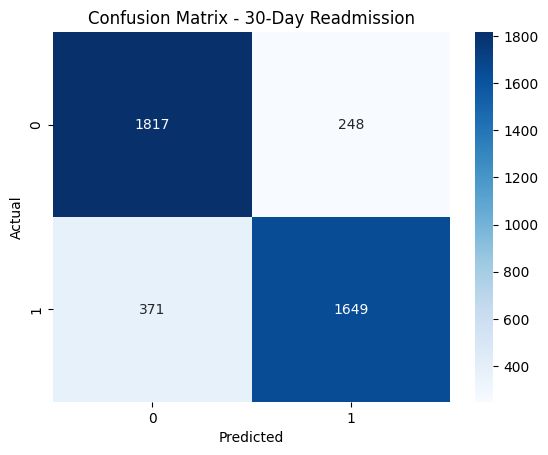

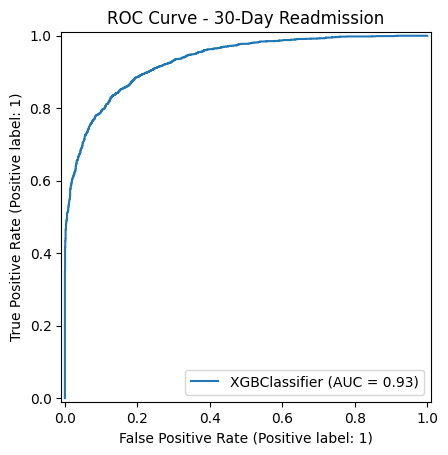


📊 Evaluation for 60-Day Readmission Model
----------------------------------------
              precision    recall  f1-score   support

           0       0.81      0.84      0.82      1895
           1       0.86      0.83      0.84      2190

    accuracy                           0.83      4085
   macro avg       0.83      0.83      0.83      4085
weighted avg       0.83      0.83      0.83      4085

ROC AUC: 0.9206


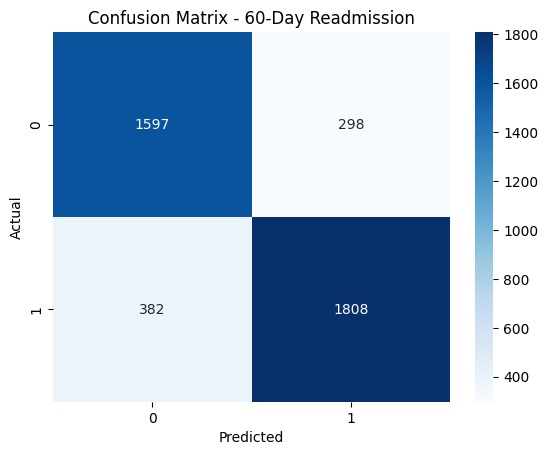

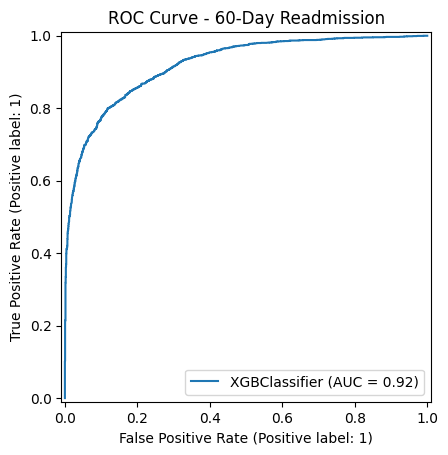

In [ ]:
# Evaluate Performance

def evaluate_model(model, X_test, y_test, label=""):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n📊 Evaluation for {label} Readmission Model")
    print("-" * 40)
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {label} Readmission")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {label} Readmission")
    plt.show()

# Evaluate both models
evaluate_model(model_30, X_test_30, y_test_30, label="30-Day")
evaluate_model(model_60, X_test_60, y_test_60, label="60-Day")

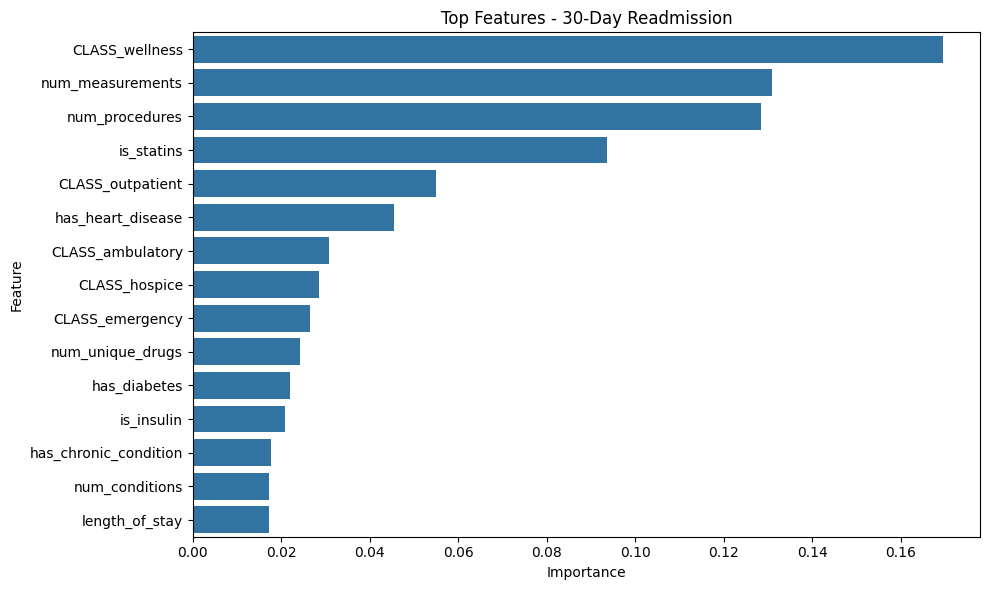

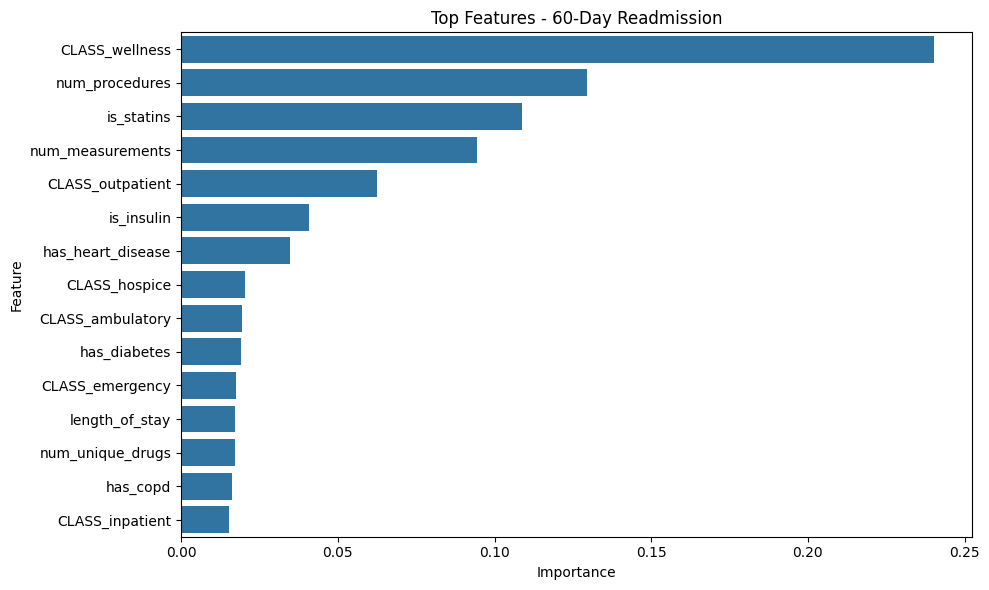

In [ ]:
# Feature Importance Viz

def plot_feature_importance(model, feature_names, top_n=15, title="Feature Importance"):
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[::-1][:top_n]
    top_features = [feature_names[i] for i in sorted_idx]
    top_importances = importances[sorted_idx]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_importances, y=top_features)
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Plot feature importance for both models
plot_feature_importance(model_30, features, title="Top Features - 30-Day Readmission")
plot_feature_importance(model_60, features, title="Top Features - 60-Day Readmission")


In [20]:
import joblib

# Save models to disk
joblib.dump(model_30, "xgb_model_30_day.pkl")
joblib.dump(model_60, "xgb_model_60_day.pkl")

print("Models saved successfully.")


Models saved successfully.


In [21]:
from google.colab import files

files.download("xgb_model_30_day.pkl")
files.download("xgb_model_60_day.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>